# 04. RL 포트폴리오 에이전트 (PPO)

**목표**: 카테고리 레벨 자산 배분을 학습하는 PPO 에이전트 → `w_RL` (10-dim) 생성

| 단계 | 내용 |
|------|------|
| 1 | 카테고리 월별 수익률 계산 |
| 2 | Gym 환경 정의 (ETFPortfolioEnv) |
| 3 | PPO 학습 (stable-baselines3) |
| 4 | 학습된 정책으로 `w_RL` 시계열 추출 |
| 5 | 결과 저장 |

**출력**: `w_RL` — RL 에이전트가 매달 추천하는 10개 카테고리 배분 비중  
**다음 노트북**: `05_bl_fusion_mvo.ipynb` 에서 역최적화 후 BL 융합

In [13]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    !pip install -q stable-baselines3[extra] gymnasium scikit-learn

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

matplotlib.rcParams['font.family'] = 'NanumGothic' if IN_COLAB else 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

if IN_COLAB:
    DRIVE_ROOT = '/content/drive/MyDrive/졸업프로젝트/GAPS_대회'
else:
    DRIVE_ROOT = os.path.expanduser('~/school/4-1/졸업프로젝트/GAPS_대회')

DATA_DIR = os.path.join(DRIVE_ROOT, 'data')
MODEL_DIR = os.path.join(DRIVE_ROOT, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)
print('DATA_DIR:', DATA_DIR)
print('MODEL_DIR:', MODEL_DIR)

DATA_DIR: /content/drive/MyDrive/졸업프로젝트/GAPS_대회/data
MODEL_DIR: /content/drive/MyDrive/졸업프로젝트/GAPS_대회/models


## Step 1 — 카테고리 월별 수익률 계산

In [15]:
# ── 카테고리 정의 ──────────────────────────────────────────────────────────────
CATEGORIES = [
    'fx_commodity',       # 위험 0
    'overseas_index',     # 위험 1
    'overseas_sector',    # 위험 2
    'domestic_index',     # 위험 3
    'domestic_sector',    # 위험 4
    'mmf_ultrashort',     # 안전 5
    'overseas_bond_corp', # 안전 6
    'overseas_bond',      # 안전 7
    'domestic_bond_corp', # 안전 8
    'domestic_bond',      # 안전 9
]
RISK_IDX = [0, 1, 2, 3, 4]   # 위험자산 카테고리 인덱스
SAFE_IDX = [5, 6, 7, 8, 9]   # 안전자산 카테고리 인덱스
N_CATS = len(CATEGORIES)
print(f'카테고리 수: {N_CATS}, 위험: {len(RISK_IDX)}개, 안전: {len(SAFE_IDX)}개')

카테고리 수: 10, 위험: 5개, 안전: 5개


In [16]:
# ── ETF 유니버스 로드 ──────────────────────────────────────────────────────────
# etf_universe.py와 동일한 ETF_LIST를 사용
# (Colab 호환성 위해 bl_meta.json + etf_close_wide.parquet 활용)

price_df = pd.read_parquet(os.path.join(DATA_DIR, 'etf_close_wide.parquet'))
price_df.index = pd.to_datetime(price_df.index)
price_df = price_df.sort_index()

with open(os.path.join(DATA_DIR, 'bl_meta.json'), encoding='utf-8') as f:
    bl_meta = json.load(f)

delta = bl_meta['delta']
r_f_annual = bl_meta['r_f']
r_f_monthly = r_f_annual / 12
tickers_final = bl_meta['tickers']

print(f'ETF 수: {len(tickers_final)}')
print(f'δ={delta:.4f}, r_f={r_f_annual:.2%}')

ETF 수: 131
δ=6.2627, r_f=3.50%


In [17]:
# ── ETF 카테고리 매핑 (etf_universe.py 인라인) ─────────────────────────────────
import sys
sys.path.insert(0, os.path.join(DRIVE_ROOT, 'src'))
try:
    from etf_universe import ETF_LIST
    print('etf_universe.py 로드 성공')
except ImportError:
    print('etf_universe.py import 실패 → 대안 경로 사용')
    ETF_LIST = None

if ETF_LIST is not None:
    etf_df = pd.DataFrame(ETF_LIST)
    etf_df = etf_df[~etf_df['special_ticker'].fillna(False).astype(bool)]
    ticker_to_cat = etf_df.set_index('ticker')['category'].to_dict()
    ticker_to_aum = etf_df.set_index('ticker')['aum'].to_dict()
    print(f'ETF_LIST 로드: {len(etf_df)}개')
else:
    raise RuntimeError('ETF_LIST를 로드할 수 없습니다. src/etf_universe.py를 확인하세요.')

etf_universe.py 로드 성공
ETF_LIST 로드: 186개


In [18]:
# ── 카테고리별 월별 수익률 계산 ────────────────────────────────────────────────
# 일별 종가 → 월별 수익률 (월말 기준)

CRIT_DATE = '2021-01-01'
price_sub = price_df.loc[CRIT_DATE:, [t for t in tickers_final if t in price_df.columns]].copy()
price_sub = price_sub.ffill()

# 월말 종가 추출
monthly_price = price_sub.resample('ME').last()
monthly_ret = monthly_price.pct_change().dropna(how='all')

# 카테고리별 AUM 가중 평균 수익률
cat_ret_dict = {}
for cat in CATEGORIES:
    cat_tickers = [t for t in tickers_final if ticker_to_cat.get(t) == cat and t in monthly_ret.columns]
    if not cat_tickers:
        cat_ret_dict[cat] = pd.Series(0.0, index=monthly_ret.index)
        continue
    aum_w = pd.Series({t: ticker_to_aum.get(t, 1.0) for t in cat_tickers})
    aum_w = aum_w / aum_w.sum()
    cat_ret_dict[cat] = (monthly_ret[cat_tickers] * aum_w).sum(axis=1)

cat_ret = pd.DataFrame(cat_ret_dict, columns=CATEGORIES)
cat_ret = cat_ret.dropna()

print(f'카테고리 수익률 행렬: {cat_ret.shape}')
print(f'기간: {cat_ret.index[0].date()} ~ {cat_ret.index[-1].date()}')
cat_ret.tail(3)

카테고리 수익률 행렬: (64, 10)
기간: 2021-02-28 ~ 2026-05-31


,fx_commodity,overseas_index,overseas_sector,domestic_index,domestic_sector,mmf_ultrashort,overseas_bond_corp,overseas_bond,domestic_bond_corp,domestic_bond
2026-03-31,-0.077531,-0.017577,0.002596,-0.189154,-0.177169,0.001848,0.030040,0.058597,-0.019767,-0.017371
2026-04-30,-0.023609,0.112498,0.137539,0.285855,0.345053,0.000615,-0.021075,-0.032010,0.002352,0.001953
2026-05-31,0.004330,0.097534,0.060964,0.229429,0.207865,0.001360,0.018673,0.015856,-0.009561,-0.006878


In [19]:
# ── 카테고리 공분산 행렬 Σ_cat (Ledoit-Wolf) ──────────────────────────────────
from sklearn.covariance import LedoitWolf

lw_cat = LedoitWolf()
lw_cat.fit(cat_ret.fillna(0).values)
Sigma_cat = lw_cat.covariance_ * 12  # 연율화 (월별 데이터이므로 ×12)

# 카테고리 균형 비중 (AUM 기반)
cat_aum = {}
for cat in CATEGORIES:
    cat_tickers = [t for t in tickers_final if ticker_to_cat.get(t) == cat]
    cat_aum[cat] = sum(ticker_to_aum.get(t, 0) for t in cat_tickers)

w_mkt_cat = np.array([cat_aum[c] for c in CATEGORIES], dtype=float)
w_mkt_cat /= w_mkt_cat.sum()

# 카테고리 균형 수익률
Pi_cat = delta * Sigma_cat @ w_mkt_cat

print('w_mkt_cat (카테고리 시장 비중):')
for c, w in zip(CATEGORIES, w_mkt_cat):
    print(f'  {c:<22s}: {w:.4%}')
print(f'\nΠ_cat 평균: {Pi_cat.mean():.4%}')

# 저장 (05 노트북에서 사용)
np.save(os.path.join(DATA_DIR, 'bl_sigma_cat.npy'), Sigma_cat)
np.save(os.path.join(DATA_DIR, 'bl_pi_cat.npy'), Pi_cat)
np.save(os.path.join(DATA_DIR, 'bl_w_mkt_cat.npy'), w_mkt_cat)
print('\nΣ_cat, Π_cat, w_mkt_cat 저장 완료')

w_mkt_cat (카테고리 시장 비중):
  fx_commodity          : 4.8469%
  overseas_index        : 33.5031%
  overseas_sector       : 4.6702%
  domestic_index        : 33.8254%
  domestic_sector       : 12.7344%
  mmf_ultrashort        : 3.4122%
  overseas_bond_corp    : 0.0273%
  overseas_bond         : 0.5416%
  domestic_bond_corp    : 4.3726%
  domestic_bond         : 2.0660%

Π_cat 평균: 9.1975%

Σ_cat, Π_cat, w_mkt_cat 저장 완료


## Step 2 — Gym 환경 정의 (ETFPortfolioEnv)

In [20]:
class ETFPortfolioEnv(gym.Env):
    """
    카테고리 레벨 ETF 포트폴리오 강화학습 환경

    State (150-dim):
        - 최근 12개월 카테고리 수익률 (12×10 = 120)
        - 카테고리 수익률 변동성 (10)
        - AI 예측 수익률 ai_pred (10, 없으면 0)
        - 전월 카테고리 비중 prev_w (10)

    Action:
        - 10-dim 연속값 (logits) → 제약 소프트맥스 적용
        - 위험자산(인덱스 0~4) 합계 ≤ 70% 보장

    Reward:
        - 월별 초과수익 - 거래비용 (편도 0.1% × 회전율)
    """

    metadata = {'render_modes': []}

    def __init__(self, cat_ret: pd.DataFrame, ai_preds: pd.DataFrame = None,
                 r_f_monthly: float = 0.035 / 12, lookback: int = 12):
        super().__init__()
        self.cat_ret = cat_ret.values.astype(np.float32)    # (T, 10)
        self.dates = cat_ret.index
        self.ai_preds = ai_preds.values.astype(np.float32) if ai_preds is not None else None
        self.r_f = r_f_monthly
        self.LOOKBACK = lookback
        self.T = len(cat_ret)
        self.N_CATS = cat_ret.shape[1]
        self.RISK_IDX = list(range(5))  # 카테고리 0~4 = 위험자산

        n_state = self.LOOKBACK * self.N_CATS + self.N_CATS + self.N_CATS + self.N_CATS
        self.observation_space = spaces.Box(
            low=-10.0, high=10.0, shape=(n_state,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-3.0, high=3.0, shape=(self.N_CATS,), dtype=np.float32
        )

        self.reset()

    # ── 핵심: 위험자산 70% 제약 소프트맥스 ────────────────────────────────────
    def _apply_risk_constraint(self, logits: np.ndarray) -> np.ndarray:
        e = np.exp(logits - logits.max())
        w = e / (e.sum() + 1e-8)

        risk_sum = w[self.RISK_IDX].sum()
        if risk_sum > 0.70:
            w[self.RISK_IDX] *= 0.70 / risk_sum
            safe_idx = [i for i in range(self.N_CATS) if i not in self.RISK_IDX]
            safe_sum = w[safe_idx].sum()
            if safe_sum < 1e-8:
                for i in safe_idx:
                    w[i] = 0.30 / len(safe_idx)
            else:
                w[safe_idx] *= 0.30 / safe_sum

        # 부동소수점 오류 정리
        w = np.clip(w, 0.0, 1.0)
        w /= w.sum()
        return w

    def _get_obs(self) -> np.ndarray:
        t = self.t
        start = max(0, t - self.LOOKBACK)
        window = self.cat_ret[start:t]  # (lookback, N_CATS)

        if len(window) < self.LOOKBACK:
            pad = np.zeros((self.LOOKBACK - len(window), self.N_CATS), dtype=np.float32)
            window = np.vstack([pad, window])

        vols = window.std(axis=0)  # (N_CATS,)

        if self.ai_preds is not None and t > 0:
            ai = self.ai_preds[min(t - 1, len(self.ai_preds) - 1)]
        else:
            ai = np.zeros(self.N_CATS, dtype=np.float32)

        obs = np.concatenate([
            window.flatten(),   # 120-dim
            vols,               # 10-dim
            ai,                 # 10-dim
            self.prev_w,        # 10-dim
        ]).astype(np.float32)

        return np.clip(obs, -10.0, 10.0)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = self.LOOKBACK
        self.prev_w = np.ones(self.N_CATS, dtype=np.float32) / self.N_CATS
        return self._get_obs(), {}

    def step(self, action):
        w = self._apply_risk_constraint(np.array(action, dtype=np.float32))

        if self.t < self.T:
            ret = self.cat_ret[self.t]
            port_ret = float((w * ret).sum())
        else:
            port_ret = 0.0

        # 거래비용: 회전율의 0.1% (편도)
        turnover = float(np.abs(w - self.prev_w).sum())
        tc = 0.001 * turnover

        # 리워드: 초과수익 - 거래비용
        reward = (port_ret - tc) - self.r_f

        self.prev_w = w.copy()
        self.t += 1
        terminated = self.t >= self.T

        info = {
            'weights': w,
            'port_ret': port_ret,
            'turnover': turnover,
            'date': str(self.dates[self.t - 1].date()) if self.t - 1 < self.T else 'end'
        }
        return self._get_obs(), float(reward), terminated, False, info


# ── 환경 검증 ────────────────────────────────────────────────────────────────
env_test = ETFPortfolioEnv(cat_ret, r_f_monthly=r_f_monthly)
check_env(env_test, warn=True)
print('환경 검증 통과')

# 제약 조건 확인
obs, _ = env_test.reset()
for _ in range(5):
    action = env_test.action_space.sample()
    obs, reward, done, _, info = env_test.step(action)
    w = info['weights']
    risk_sum = w[[0,1,2,3,4]].sum()
    assert risk_sum <= 0.701, f'위험자산 제약 위반: {risk_sum:.4f}'
    assert abs(w.sum() - 1.0) < 1e-5, f'합계 ≠ 1: {w.sum():.6f}'
print('제약 조건 검증 통과 (위험자산 ≤70%, 합계=1.0)')

환경 검증 통과
제약 조건 검증 통과 (위험자산 ≤70%, 합계=1.0)


## Step 3 — PPO 학습

In [21]:
# ── 학습/평가 데이터 분리 ────────────────────────────────────────────────────
# 학습: 2021-01 ~ 2024-12, 평가(테스트): 2025-01 ~ 2026-05

train_end = '2024-12-31'
cat_ret_train = cat_ret.loc[:train_end]
cat_ret_test  = cat_ret.loc['2025-01-01':]

print(f'학습 기간: {cat_ret_train.index[0].date()} ~ {cat_ret_train.index[-1].date()} ({len(cat_ret_train)}개월)')
print(f'테스트 기간: {cat_ret_test.index[0].date()} ~ {cat_ret_test.index[-1].date()} ({len(cat_ret_test)}개월)')

학습 기간: 2021-02-28 ~ 2024-12-31 (47개월)
테스트 기간: 2025-01-31 ~ 2026-05-31 (17개월)


In [22]:
# ── ai_pred 로드 (02b 노트북 출력) ─────────────────────────────────────────
AI_PRED_PATH = os.path.join(DATA_DIR, 'ai_pred_monthly.parquet')

if os.path.exists(AI_PRED_PATH):
    ai_pred_df = pd.read_parquet(AI_PRED_PATH)
    ai_pred_df.index = pd.to_datetime(ai_pred_df.index)
    # 학습/테스트 기간 분리
    ai_pred_train = ai_pred_df.loc[:train_end]
    ai_pred_test  = ai_pred_df.loc['2025-01-01':]
    print(f'ai_pred 로드 완료: {ai_pred_df.shape}')
    USE_AI_PRED = True
else:
    ai_pred_train = None
    ai_pred_test  = None
    USE_AI_PRED = False
    print('ai_pred 없음 — 02b_etf_hybrid_model_colab.ipynb를 먼저 실행하세요')


# ── PPO 학습 ────────────────────────────────────────────────────────────────
train_env = Monitor(ETFPortfolioEnv(cat_ret_train, ai_preds=ai_pred_train, r_f_monthly=r_f_monthly))
eval_env  = Monitor(ETFPortfolioEnv(cat_ret_test,  ai_preds=ai_pred_test,  r_f_monthly=r_f_monthly))

model = PPO(
    policy='MlpPolicy',
    env=train_env,
    n_steps=len(cat_ret_train) - 12,
    batch_size=32,
    n_epochs=10,
    learning_rate=3e-4,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs=dict(net_arch=[256, 256, 128]),
    verbose=1,
    seed=42,
)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=MODEL_DIR,
    log_path=MODEL_DIR,
    eval_freq=max(1, (len(cat_ret_train) - 12) * 5),
    n_eval_episodes=1,
    deterministic=True,
    verbose=0,
)

TOTAL_TIMESTEPS = (len(cat_ret_train) - 12) * 200
print(f'학습 timesteps: {TOTAL_TIMESTEPS:,}')
print(f'AI 예측 신호 사용: {USE_AI_PRED}')

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=eval_callback,
    progress_bar=True,
)

model.save(os.path.join(MODEL_DIR, 'ppo_etf_portfolio'))
print('모델 저장 완료')


ai_pred 로드 완료: (64, 10)
Using cpu device
Wrapping the env in a DummyVecEnv.


Output()

학습 timesteps: 7,000
AI 예측 신호 사용: True
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 35       |
|    ep_rew_mean     | 0.14     |
| time/              |          |
|    fps             | 218      |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 35       |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 35         |
|    ep_rew_mean          | 0.158      |
| time/                   |            |
|    fps                  | 133        |
|    iterations           | 2          |
|    time_elapsed         | 0          |
|    total_timesteps      | 70         |
| train/                  |            |
|    approx_kl            | 0.00762662 |
|    clip_fraction        | 0.063      |
|    clip_range           | 0.2        |
|    entropy_loss         | -14.2      |
|    explained_variance   | -6.44      |
|    le

모델 저장 완료


## Step 4 — 학습된 정책으로 `w_RL` 추출

In [23]:
# ── 최적 모델 로드 ────────────────────────────────────────────────────────────
best_model_path = os.path.join(MODEL_DIR, 'best_model')
if os.path.exists(best_model_path + '.zip'):
    model_best = PPO.load(best_model_path)
    print('best_model 로드')
else:
    model_best = model
    print('학습 완료 모델 사용')


def extract_weights(model, cat_ret_df, r_f_monthly=0.035/12):
    """학습된 정책으로 전체 기간 w_RL 시계열 추출"""
    env = ETFPortfolioEnv(cat_ret_df, r_f_monthly=r_f_monthly)
    obs, _ = env.reset()

    weights_list = []
    dates_list = []
    returns_list = []

    while True:
        action, _ = model_best.predict(obs, deterministic=True)
        obs, reward, terminated, _, info = env.step(action)

        weights_list.append(info['weights'])
        dates_list.append(info['date'])
        returns_list.append(info['port_ret'])

        if terminated:
            break

    dates_valid = cat_ret_df.index[12:].tolist()
    n = min(len(weights_list), len(dates_valid))

    w_df = pd.DataFrame(
        weights_list[:n],
        index=dates_valid[:n],
        columns=CATEGORIES
    )
    ret_s = pd.Series(returns_list[:n], index=dates_valid[:n], name='port_ret')
    return w_df, ret_s


# 전체 기간 (학습 + 테스트) w_RL 추출
w_RL_full, ret_full = extract_weights(model_best, cat_ret)
print(f'w_RL 추출 완료: {w_RL_full.shape}')
print(f'기간: {w_RL_full.index[0].date()} ~ {w_RL_full.index[-1].date()}')

# 제약 조건 확인
risk_sums = w_RL_full.iloc[:, :5].sum(axis=1)
print(f'\n위험자산 비중 통계:')
print(f'  최대: {risk_sums.max():.4%}  (≤70% 충족: {(risk_sums <= 0.701).all()})')
print(f'  평균: {risk_sums.mean():.4%}')
print(f'  최소: {risk_sums.min():.4%}')

w_RL_full.tail(3)

best_model 로드
w_RL 추출 완료: (52, 10)
기간: 2022-02-28 ~ 2026-05-31

위험자산 비중 통계:
  최대: 60.4595%  (≤70% 충족: True)
  평균: 53.9189%
  최소: 47.6857%


,fx_commodity,overseas_index,overseas_sector,domestic_index,domestic_sector,mmf_ultrashort,overseas_bond_corp,overseas_bond,domestic_bond_corp,domestic_bond
2026-03-31,0.081687,0.118390,0.153922,0.079762,0.127410,0.124870,0.054196,0.070883,0.073270,0.115610
2026-04-30,0.099535,0.060387,0.125242,0.151414,0.070851,0.110912,0.084916,0.092616,0.068331,0.135798
2026-05-31,0.078614,0.158596,0.101897,0.096821,0.134836,0.123703,0.069615,0.068022,0.073179,0.094718


In [ ]:
# ── 성과 분석 ────────────────────────────────────────────────────────────────
# ⚠️  '전체 기간' 수치는 훈련 구간(2022-02 ~ 2024-12)을 포함한 in-sample 참고값입니다.
#     05_bl_fusion_mvo.ipynb 의 백테스트는 OOS 구간(2025-01~)만 사용합니다.

def sharpe(returns, r_f=0.035/12, periods_per_year=12):
    excess = returns - r_f
    if excess.std() == 0:
        return 0.0
    return excess.mean() / excess.std() * np.sqrt(periods_per_year)

def max_drawdown(returns):
    cumret = (1 + returns).cumprod()
    roll_max = cumret.cummax()
    dd = (cumret - roll_max) / roll_max
    return dd.min()

# 전체 기간 (참고용 — in-sample 포함)
full_sharpe = sharpe(ret_full)
full_cagr   = (1 + ret_full).prod() ** (12 / len(ret_full)) - 1
full_mdd    = max_drawdown(ret_full)

# 테스트 기간만 (OOS — 이 수치가 신뢰할 수 있는 평가)
ret_test_period = ret_full[ret_full.index >= pd.Timestamp('2025-01-01')]
ret_train_period = ret_full[ret_full.index < pd.Timestamp('2025-01-01')]

print('=== RL 에이전트 성과 =========================')
print(f'⚠️  전체 기간 (in-sample 포함, 참고용):')
print(f'  기간   : {ret_full.index[0].date()} ~ {ret_full.index[-1].date()} ({len(ret_full)}개월)')
print(f'  CAGR   : {full_cagr:.2%}  ← 훈련 구간 포함으로 과대평가될 수 있음')
print(f'  Sharpe : {full_sharpe:.3f}')
print(f'  MDD    : {full_mdd:.2%}')
print()
if len(ret_test_period) > 0:
    test_cagr   = (1 + ret_test_period).prod() ** (12 / len(ret_test_period)) - 1
    test_sharpe = sharpe(ret_test_period)
    test_mdd    = max_drawdown(ret_test_period)
    print(f'✅  OOS 테스트 기간 (신뢰할 수 있는 평가):')
    print(f'  기간   : {ret_test_period.index[0].date()} ~ {ret_test_period.index[-1].date()} ({len(ret_test_period)}개월)')
    print(f'  CAGR   : {test_cagr:.2%}')
    print(f'  Sharpe : {test_sharpe:.3f}')
    print(f'  MDD    : {test_mdd:.2%}')
    print()
    print('  ※ 05_bl_fusion_mvo.ipynb 의 BL 백테스트는 이 OOS 구간만 사용합니다.')

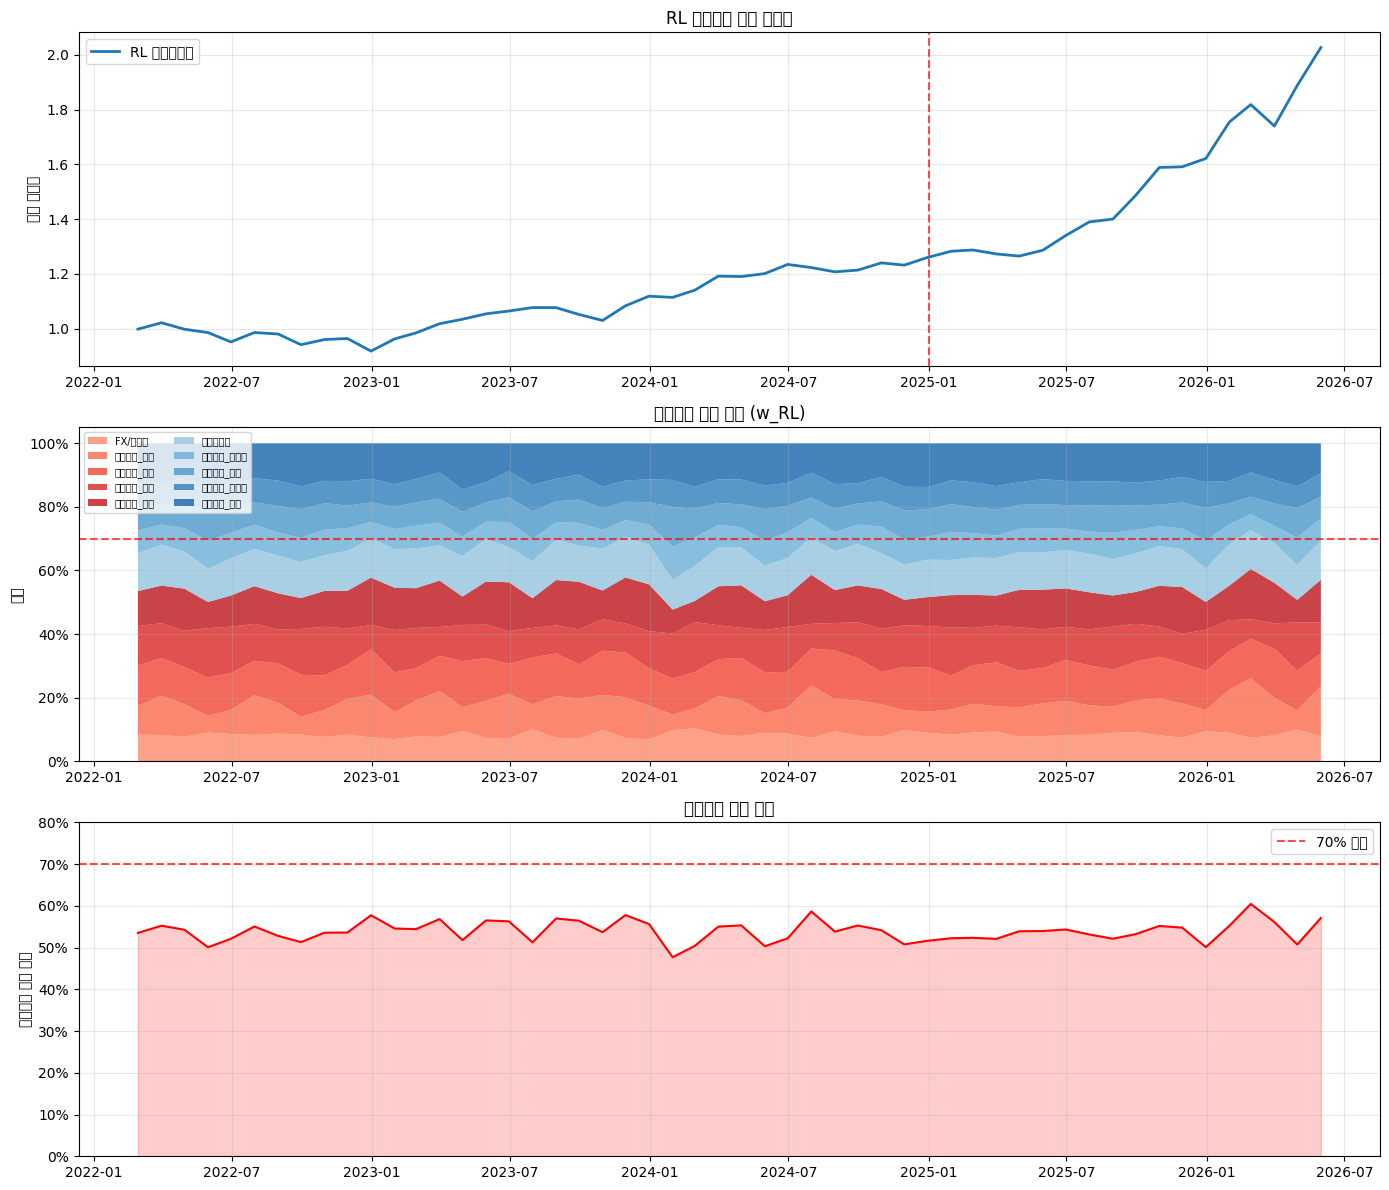

In [25]:
# ── 시각화 ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. 누적 수익률
cumret = (1 + ret_full).cumprod()
axes[0].plot(cumret.index, cumret.values, label='RL 포트폴리오', linewidth=2)
axes[0].set_title('RL 에이전트 누적 수익률')
axes[0].set_ylabel('누적 수익률')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axvline(pd.Timestamp('2025-01-01'), color='red', linestyle='--',
                alpha=0.7, label='학습/테스트 경계')

# 2. 카테고리 배분 비중 (스택 영역)
w_plot = w_RL_full.copy()
cat_labels_kr = ['FX/원자재', '해외주식_지수', '해외주식_섹터',
                  '국내주식_지수', '국내주식_섹터',
                  '초단기채권', '해외채권_회사채', '해외채권_종합',
                  '국내채권_회사채', '국내채권_종합']
colors_risk = plt.cm.Reds(np.linspace(0.4, 0.8, 5))
colors_safe = plt.cm.Blues(np.linspace(0.4, 0.8, 5))
colors = list(colors_risk) + list(colors_safe)

axes[1].stackplot(w_plot.index, w_plot.values.T,
                   labels=cat_labels_kr, colors=colors, alpha=0.8)
axes[1].set_title('카테고리 배분 비중 (w_RL)')
axes[1].set_ylabel('비중')
axes[1].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
axes[1].legend(loc='upper left', fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0.70, color='red', linestyle='--', alpha=0.7, label='위험자산 70% 한도')

# 3. 위험자산 비중 추이
risk_sums = w_RL_full.iloc[:, :5].sum(axis=1)
axes[2].plot(risk_sums.index, risk_sums.values, color='red', linewidth=1.5)
axes[2].axhline(0.70, color='red', linestyle='--', alpha=0.7, label='70% 한도')
axes[2].fill_between(risk_sums.index, 0, risk_sums.values, alpha=0.2, color='red')
axes[2].set_title('위험자산 비중 추이')
axes[2].set_ylabel('위험자산 합계 비중')
axes[2].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
axes[2].set_ylim(0, 0.80)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'rl_portfolio_result.png'), dpi=150)
plt.show()

## Step 5 — 결과 저장

In [26]:
# ── w_RL 시계열 저장 ─────────────────────────────────────────────────────────
# 05_bl_fusion_mvo.ipynb에서 역최적화 변환에 사용

w_RL_full.to_parquet(os.path.join(DATA_DIR, 'rl_w_RL.parquet'))
ret_full.to_csv(os.path.join(DATA_DIR, 'rl_portfolio_returns.csv'))

print('저장 완료:')
print(f'  rl_w_RL.parquet       — w_RL 시계열 ({w_RL_full.shape})')
print(f'  rl_portfolio_returns.csv — RL 포트폴리오 수익률 ({len(ret_full)}개월)')
print(f'  rl_portfolio_result.png — 시각화')
print(f'  models/ppo_etf_portfolio.zip — 학습된 PPO 모델')
print()
print('다음 단계: 05_bl_fusion_mvo.ipynb')
print('  → w_RL + w_Human 역최적화 → BL 융합 → MVO → w*')

저장 완료:
  rl_w_RL.parquet       — w_RL 시계열 ((52, 10))
  rl_portfolio_returns.csv — RL 포트폴리오 수익률 (52개월)
  rl_portfolio_result.png — 시각화
  models/ppo_etf_portfolio.zip — 학습된 PPO 모델

다음 단계: 05_bl_fusion_mvo.ipynb
  → w_RL + w_Human 역최적화 → BL 융합 → MVO → w*


## 결과 요약

| 산출물 | 설명 | 다음 단계 활용 |
|--------|------|---------------|
| `rl_w_RL.parquet` | RL 에이전트 월별 카테고리 배분 비중 | 역최적화 → `Q_RL = δΣw_RL` |
| `bl_sigma_cat.npy` | 10×10 카테고리 공분산 행렬 | BL 역최적화 및 사후 계산 |
| `bl_pi_cat.npy` | 10-dim 카테고리 균형 수익률 | BL Prior |
| `rl_portfolio_returns.csv` | RL 포트폴리오 수익률 | 성과 비교 |

**다음 노트북**: `05_bl_fusion_mvo.ipynb`
- `w_RL` → 역최적화 → `Q_RL`
- `w_Human` → 역최적화 → `Q_Human`  
- BL 융합 → `E[R]_cat`  
- MVO (scipy, 하드 제약) → `w*`  
- 월별 롤링 백테스트